In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind



In [60]:
df=pd.read_csv('/content/HDB Resale Price.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

In [61]:
df.head(5)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,265000.0


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196686 entries, 0 to 196685
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                196686 non-null  object 
 1   town                 196686 non-null  object 
 2   flat_type            196686 non-null  object 
 3   block                196686 non-null  object 
 4   street_name          196686 non-null  object 
 5   storey_range         196686 non-null  object 
 6   floor_area_sqm       196686 non-null  float64
 7   flat_model           196686 non-null  object 
 8   lease_commence_date  196686 non-null  int64  
 9   resale_price         196686 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 15.0+ MB


In [63]:
##Checking for missing values
df.isna().sum()

,0
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
resale_price,0


In [64]:
##Format the month column to extract the month and year
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
df['Formatted_Month'] = df['month'].apply(lambda x: x.strftime('%b %Y'))
df['year']=df['Formatted_Month'].str.split().str[1]

In [65]:
df.tail()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Formatted_Month,year
196681,2024-12-01,YISHUN,EXECUTIVE,834,YISHUN ST 81,07 TO 09,142.0,Apartment,1988,950000.0,Dec 2024,2024
196682,2024-12-01,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,146.0,Maisonette,1988,990000.0,Dec 2024,2024
196683,2024-02-01,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,04 TO 06,164.0,Multi Generation,1987,998000.0,Feb 2024,2024
196684,2024-03-01,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,10 TO 12,164.0,Multi Generation,1987,1200000.0,Mar 2024,2024
196685,2024-06-01,YISHUN,MULTI-GENERATION,633,YISHUN ST 61,07 TO 09,171.0,Multi Generation,1987,1028000.0,Jun 2024,2024


In [66]:
##Checking for duplicate rows
df.duplicated().sum()

372

In [67]:
##Listing the duplicate rows
df[df.duplicated(keep=False)]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Formatted_Month,year
75,2017-01-01,BEDOK,3 ROOM,709,BEDOK RESERVOIR RD,07 TO 09,68.0,New Generation,1981,310000.0,Jan 2017,2017
77,2017-01-01,BEDOK,3 ROOM,709,BEDOK RESERVOIR RD,07 TO 09,68.0,New Generation,1981,310000.0,Jan 2017,2017
224,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,470000.0,Jan 2017,2017
243,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,470000.0,Jan 2017,2017
304,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,470000.0,Jan 2017,2017
305,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,470000.0,Jan 2017,2017
505,2017-01-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,470000.0,Jan 2017,2017
510,2017-01-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,470000.0,Jan 2017,2017
533,2017-01-01,JURONG WEST,4 ROOM,337A,TAH CHING RD,19 TO 21,92.0,Model A,2010,470000.0,Jan 2017,2017
591,2017-01-01,JURONG WEST,4 ROOM,337A,TAH CHING RD,19 TO 21,92.0,Model A,2010,470000.0,Jan 2017,2017


In [68]:
##Drop the duplicate rows
df.drop_duplicates(inplace=True)

In [69]:
df.duplicated().sum()

0

In [70]:
##Summary statitics for columns
df.describe()

,month,floor_area_sqm,lease_commence_date,resale_price
count,196314,196314.000000,196314.000000,1.963140e+05
mean,2021-03-14 15:22:58.758519808,97.014394,1996.181724,5.079947e+05
min,2017-01-01 00:00:00,31.000000,1966.000000,1.400000e+05
25%,2019-05-01 00:00:00,82.000000,1985.000000,3.760000e+05
50%,2021-05-01 00:00:00,93.000000,1996.000000,4.780000e+05
75%,2023-02-01 00:00:00,112.000000,2011.000000,6.080000e+05
max,2024-12-01 00:00:00,366.700000,2021.000000,1.588000e+06
std,NaN,24.036178,14.142821,1.776956e+05


In [71]:

df["town"].value_counts()

,count
town,
SENGKANG,16194
PUNGGOL,14555
WOODLANDS,13956
YISHUN,13396
TAMPINES,13179
JURONG WEST,13015
BEDOK,10316
HOUGANG,9875
CHOA CHU KANG,8968


In [72]:
###Mapping the town to their specific regions
regions_dict = {
    "SEMBAWANG": 'North', "WOODLANDS": 'North', "YISHUN": 'North',
    "ANG MO KIO": 'North East', "HOUGANG": 'North East', "PUNGGOL": 'North East',
    "SENGKANG": 'North East', "SERANGOON": 'North East',
    "BISHAN": 'Central', "BUKIT MERAH": 'Central', "BUKIT TIMAH": 'Central',
    "CENTRAL AREA": 'Central', "GEYLANG": 'Central', "KALLANG/WHAMPOA": 'Central',
    "MARINE PARADE": 'Central', "QUEENSTOWN": 'Central', "TOA PAYOH": 'Central',
    "BEDOK": 'East', "PASIR RIS": 'East', "TAMPINES": 'East',
    "BUKIT BATOK": 'West', "BUKIT PANJANG": 'West', "CHOA CHU KANG": 'West',
    "CLEMENTI": 'West', "JURONG EAST": 'West', "JURONG WEST": 'West'
}
df['regions']=df['town'].map(regions_dict)

In [73]:
##Normalizing the resale prices by dividing it by the floor area
df['resale_price_sqm'] = (df['resale_price'] / df['floor_area_sqm']).round(2)

In [74]:
df.tail()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Formatted_Month,year,regions,resale_price_sqm
196681,2024-12-01,YISHUN,EXECUTIVE,834,YISHUN ST 81,07 TO 09,142.0,Apartment,1988,950000.0,Dec 2024,2024,North,6690.14
196682,2024-12-01,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,146.0,Maisonette,1988,990000.0,Dec 2024,2024,North,6780.82
196683,2024-02-01,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,04 TO 06,164.0,Multi Generation,1987,998000.0,Feb 2024,2024,North,6085.37
196684,2024-03-01,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,10 TO 12,164.0,Multi Generation,1987,1200000.0,Mar 2024,2024,North,7317.07
196685,2024-06-01,YISHUN,MULTI-GENERATION,633,YISHUN ST 61,07 TO 09,171.0,Multi Generation,1987,1028000.0,Jun 2024,2024,North,6011.70


##EDA##


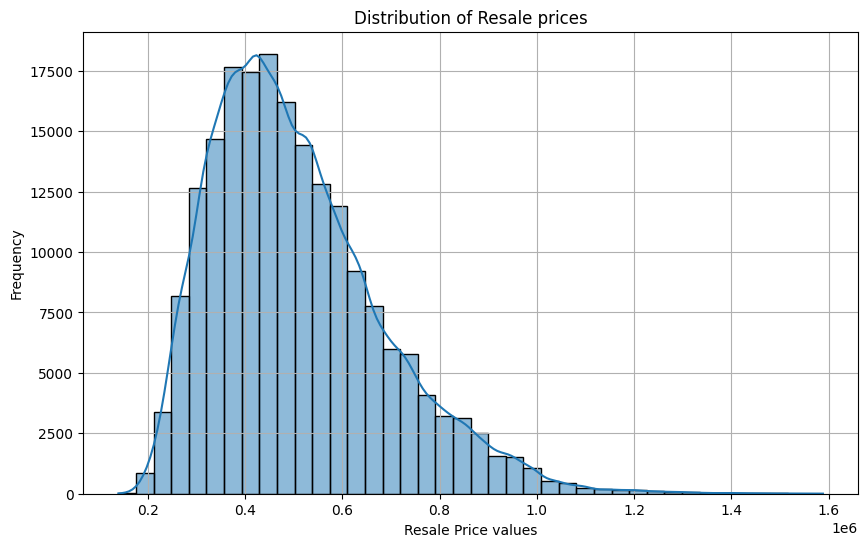

In [75]:
##Distribution of Resale prices
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='resale_price',bins=40,kde=True)
plt.title('Distribution of Resale prices')
plt.xlabel('Resale Price values')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()





*   The histogram is skewed to the right most resale prices are concentrated on the lower end while fewer properties have very high resale prices.
*  The highest frequency occurs between 400,000 and 500,000, indicating that most resale prices fall in this range.








In [76]:
df['resale_price'].describe()

,resale_price
count,1.963140e+05
mean,5.079947e+05
std,1.776956e+05
min,1.400000e+05
25%,3.760000e+05
50%,4.780000e+05
75%,6.080000e+05
max,1.588000e+06




*   Mean resale price  507,994.7
*   Minium price 140,000
*   Max price 1,588,000
*   Median price 478,000
*   Std 177,695.6

















In [77]:
##calculating median resale price
df['median_resale_price_sqm'] = df.groupby(['regions', 'year'])['resale_price_sqm'].transform('median')

###Ranking towns by Transaction volume ###

       regions             town  transaction_volume
1   North East         SENGKANG           108681787
2   North East          PUNGGOL            98941893
3         West      JURONG WEST            74229761
4   North East          HOUGANG            66047404
5        North        WOODLANDS            58266055
6        North           YISHUN            55960428
7   North East       ANG MO KIO            52996435
8         West    CHOA CHU KANG            51878436
9         East         TAMPINES            49271570
10        West      BUKIT BATOK            46069474
11        West    BUKIT PANJANG            40622399
12        East            BEDOK            38312649
13     Central      BUKIT MERAH            34905751
14     Central        TOA PAYOH            28356338
15     Central  KALLANG/WHAMPOA            27925954
16     Central       QUEENSTOWN            25251665
17        West         CLEMENTI            25016725
18       North        SEMBAWANG            23481133
19  North Ea

<ipython-input-78-499393c8dd08>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transaction_volume', y='town', data=top_towns, palette='viridis')


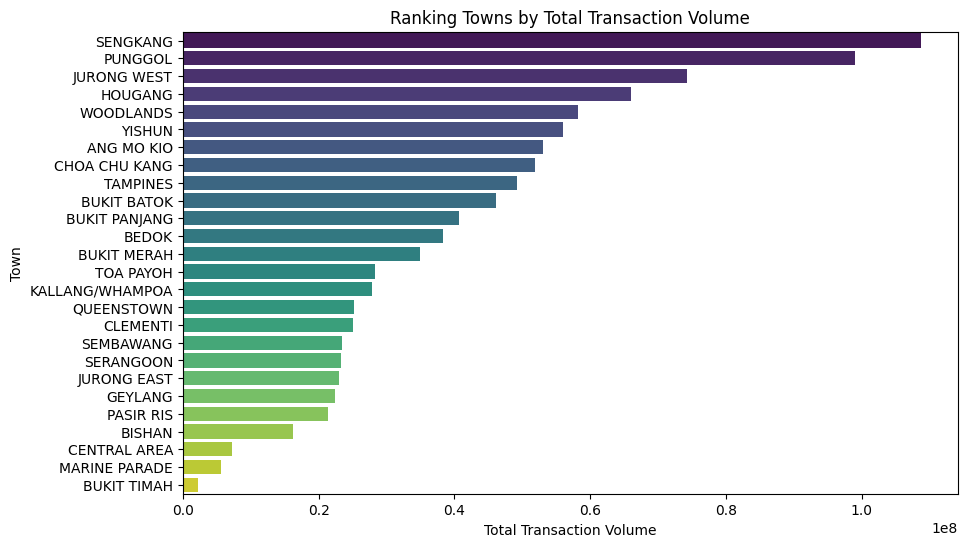

In [78]:
##Calculating the total transaction volume for each town grouped by regions
df['transaction_volume'] = df.groupby(['regions', 'year'])['regions'].transform('count')
towns_total_volume = df.groupby(['regions','town'])['transaction_volume'].sum().reset_index()
##Sorting the values in the descending order to have the top towns on the list followed by the other towns
towns_total_volume_sorted = towns_total_volume.sort_values(by='transaction_volume',ascending=False)
top_towns = towns_total_volume_sorted.head(30)
top_towns.reset_index(drop=True, inplace=True)
top_towns.index = top_towns.index + 1
print(top_towns)
plt.figure(figsize=(10, 6))
sns.barplot(x='transaction_volume', y='town', data=top_towns, palette='viridis')
plt.title('Ranking Towns by Total Transaction Volume')
plt.xlabel('Total Transaction Volume')
plt.ylabel('Town')
plt.show()

In [79]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'Formatted_Month', 'year', 'regions',
       'resale_price_sqm', 'median_resale_price_sqm', 'transaction_volume'],
      dtype='object')

###Ranking towns by Resale Price ###

       regions             town  resale_price_sqm
1      Central     CENTRAL AREA          7469.880
2      Central       QUEENSTOWN          7203.390
3      Central      BUKIT MERAH          6652.170
4      Central      BUKIT TIMAH          6635.160
5      Central           BISHAN          6190.480
6      Central    MARINE PARADE          6157.890
7      Central  KALLANG/WHAMPOA          5951.460
8         West         CLEMENTI          5543.480
9   North East          PUNGGOL          5514.710
10     Central        TOA PAYOH          5444.985
11     Central          GEYLANG          5362.045
12  North East        SERANGOON          5349.795
13  North East         SENGKANG          5052.630
14  North East       ANG MO KIO          5000.000
15        East         TAMPINES          4952.380
16        East            BEDOK          4899.495
17  North East          HOUGANG          4886.880
18        West      BUKIT BATOK          4884.620
19        West    BUKIT PANJANG          4730.975


<ipython-input-80-c062d34adb69>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='resale_price_sqm', y='town', data=top_towns_resale, palette='viridis')


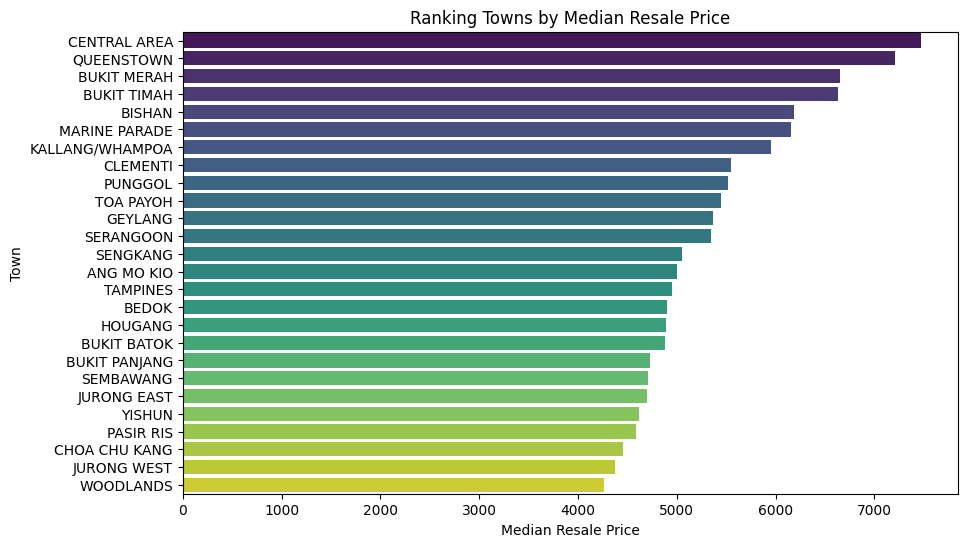

In [80]:
##Calculating the median resale price for each town grouped by region
towns_resale_price = df.groupby(['regions','town'])['resale_price_sqm'].median().reset_index()
##Sorting the resale price values to have the top performing towns on the list followed by the other towns
towns_resale_price_sorted = towns_resale_price.sort_values(by='resale_price_sqm', ascending=False)
top_towns_resale = towns_resale_price_sorted.head(30)
top_towns_resale.reset_index(drop=True, inplace=True)
top_towns_resale.index = top_towns_resale.index + 1
print(top_towns_resale)
plt.figure(figsize=(10, 6))
sns.barplot(x='resale_price_sqm', y='town', data=top_towns_resale, palette='viridis')
plt.title('Ranking Towns by Median Resale Price')
plt.xlabel('Median Resale Price')
plt.ylabel('Town')
plt.show()


In [81]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'Formatted_Month', 'year', 'regions',
       'resale_price_sqm', 'median_resale_price_sqm', 'transaction_volume'],
      dtype='object')

##Combined ranking score: Ranking towns by transaction volume and resale price###

       regions             town  resale_price_rank  transaction_volume_rank  combined_rank
1   North East          PUNGGOL                9.0                      2.0           11.0
2   North East         SENGKANG               13.0                      1.0           14.0
3      Central      BUKIT MERAH                3.0                     13.0           16.0
4      Central       QUEENSTOWN                2.0                     16.0           18.0
5   North East          HOUGANG               17.0                      4.0           21.0
6   North East       ANG MO KIO               14.0                      7.0           21.0
7      Central  KALLANG/WHAMPOA                7.0                     15.0           22.0
8      Central        TOA PAYOH               10.0                     14.0           24.0
9         East         TAMPINES               15.0                      9.0           24.0
10        West         CLEMENTI                8.0                     17.0           25.0

<ipython-input-82-de291010e115>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='combined_rank', y='town', data=final_ranked_towns.head(30), palette='viridis')


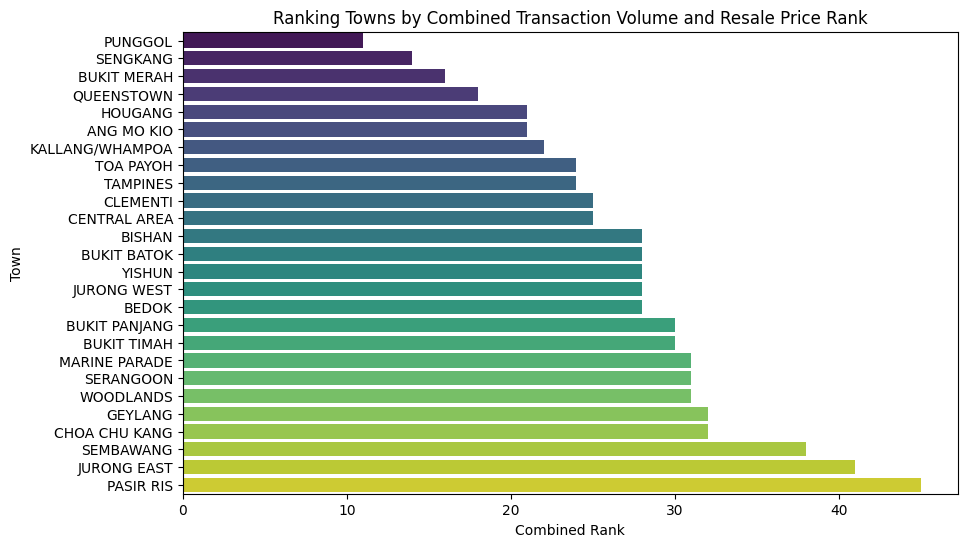

In [82]:
##Calculating the combined score for transaction volume and resale price for town grouped region
towns_resale_price = df.groupby(['regions', 'town'])['resale_price_sqm'].median().reset_index()
towns_resale_price['resale_price_rank'] = towns_resale_price['resale_price_sqm'].rank(ascending=False)
towns_total_volume = df.groupby(['regions','town'])['transaction_volume'].sum().reset_index()
towns_total_volume['transaction_volume_rank'] = towns_total_volume['transaction_volume'].rank(ascending=False)
towns_combined = pd.merge(towns_resale_price, towns_total_volume, on=['regions', 'town'])

##Combined rank score is obtained by summing up the resale price rank score and transaction volume rank score
towns_combined['combined_rank'] = towns_combined['resale_price_rank'] + towns_combined['transaction_volume_rank']
towns_combined_sorted = towns_combined.sort_values(by='combined_rank')
towns_combined_sorted.reset_index(drop=True, inplace=True)
towns_combined_sorted.index = towns_combined_sorted.index + 1
final_ranked_towns = towns_combined_sorted[['regions', 'town', 'resale_price_rank', 'transaction_volume_rank', 'combined_rank']]
print(final_ranked_towns.head(30))
plt.figure(figsize=(10, 6))
sns.barplot(x='combined_rank', y='town', data=final_ranked_towns.head(30), palette='viridis')
plt.title('Ranking Towns by Combined Transaction Volume and Resale Price Rank')
plt.xlabel('Combined Rank')
plt.ylabel('Town')
plt.show()


**###Top 5 Areas with high investment potential for the future###**
Punggol and Sengkang from the Northeast (NE) region rank first and second in terms of high transaction volumes and resale prices over the years, followed by Bukit Merah and Queenstown from the Central region, and Hougang from North east region.
**For Buyers:High Demand Areas for Investment**
Punggol and Sengkang in the Northeast region have consistently ranked first and second in transaction volume and resale prices indicating strong demand and potential for value growth
Buyers looking for long-term investment or good rental yields may find these areas attractive.

**For Sellers:Opportunity to sell at profit**
If you own a property in Punggol and Sengkang, now may be a good time to sell due to strong resale prices and high demand.
Sellers in Hougang can take advantage of its increasing popularity and demand among homebuyers looking for well-connected yet relatively affordable homes.



**Hypothesis testing**




* **Null Hypothesis (HO)**:There is no significant difference in resale price and transaction volume between the top 5 towns and the remaining towns.
* **Alternate Hypothesis (H1)**:The top 5 towns have significantly higher resale prices and transaction volumes than the remaining towns.






# ***Hypothesis testing for combined ranking of towns***

T-test for Resale Price: T-statistic = 145.358849, P-value = 0.00
Reject Null Hypothesis: There is a significant difference between top 5 towns and other towns for Resale Price
T-test for Transaction Volume: T-statistic = 146.581542, P-value = 0.00
Reject Null Hypothesis: There is a significant difference between top 5 towns and other towns for Transaction Volume.


<ipython-input-83-0e333b38ce84>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='resale_price_sqm', data=combined_data, palette='Set2', ax=axes[0])
<ipython-input-83-0e333b38ce84>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='transaction_volume', data=combined_data, palette='Set2', ax=axes[1])


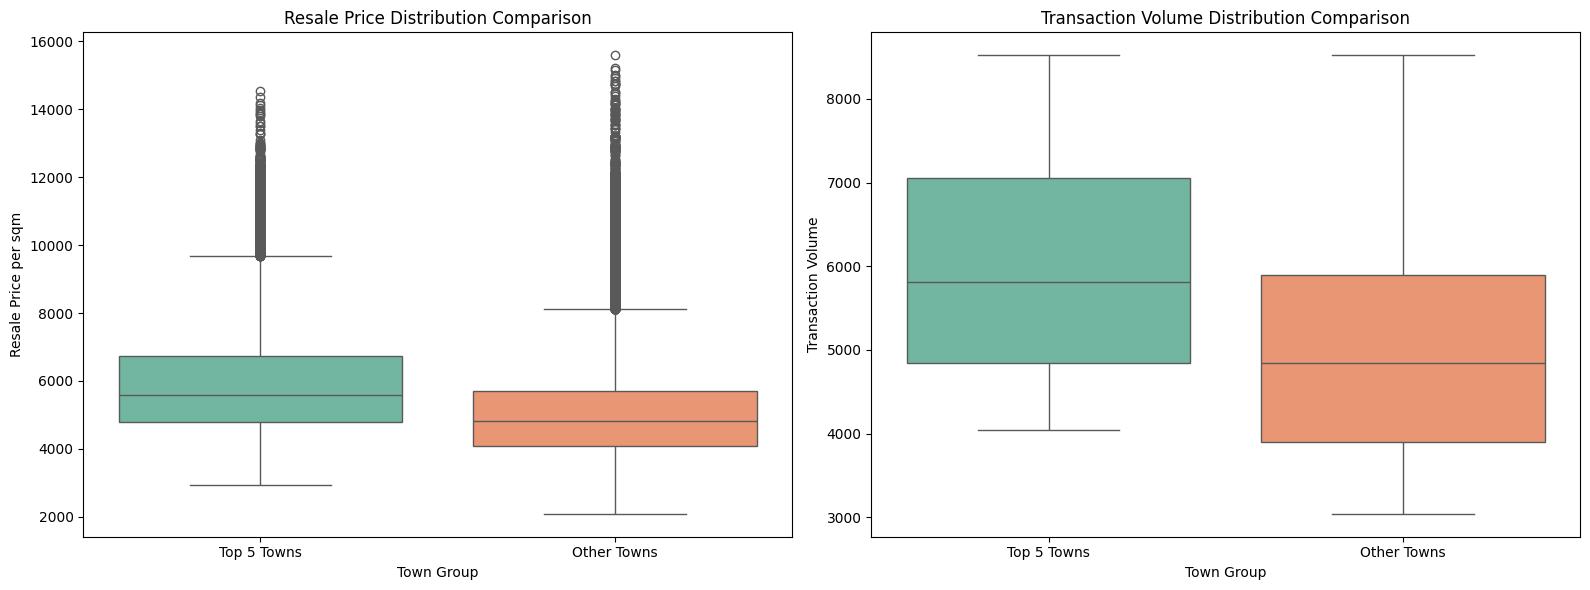

In [83]:
##Performing hypothesis testing to confirm that the top 5 towns are statistically different from the other towns
towns_resale_price = df.groupby(['regions', 'town'])['resale_price_sqm'].mean().reset_index()
towns_resale_price['resale_price_rank'] = towns_resale_price['resale_price_sqm'].rank(ascending=False)
towns_total_volume = df.groupby(['regions', 'town'])['transaction_volume'].sum().reset_index()
towns_total_volume['txn_volume_rank'] = towns_total_volume['transaction_volume'].rank(ascending=False)
towns_combined = pd.merge(towns_resale_price, towns_total_volume, on=['regions', 'town'])
towns_combined['combined_rank'] = towns_combined['resale_price_rank'] + towns_combined['txn_volume_rank']
towns_combined_sorted = towns_combined.sort_values(by='combined_rank')
towns_combined_sorted.reset_index(drop=True, inplace=True)

# Select top 5 towns
top_5_towns = towns_combined_sorted.head(5)['town'].tolist()

# Split the data into top 5 towns and remaining towns
top_5_data = df[df['town'].isin(top_5_towns)]
other_towns_data = df[~df['town'].isin(top_5_towns)]

top_5_prices = top_5_data['median_resale_price_sqm']
other_prices = other_towns_data['median_resale_price_sqm']

top_5_txn = top_5_data['transaction_volume']
other_txn = other_towns_data['transaction_volume']

##Performing independent t-test between the top 5 and the remaining towns

t_stat_price, p_value_price = ttest_ind(top_5_prices, other_prices)
t_stat_txn, p_value_txn = ttest_ind(top_5_txn, other_txn)

print(f"T-test for Resale Price: T-statistic = {t_stat_price:.6f}, P-value = {p_value_price:.2f}")
if p_value_price < 0.05:
    print("Reject Null Hypothesis: There is a significant difference between top 5 towns and other towns for Resale Price")
else:
    print("Fail to Reject Null Hypothesis: There is no significant difference between top 5 towns and other towns for Resale Price")

print(f"T-test for Transaction Volume: T-statistic = {t_stat_txn:.6f}, P-value = {p_value_txn:.2f}")
if p_value_txn < 0.05:
    print("Reject Null Hypothesis: There is a significant difference between top 5 towns and other towns for Transaction Volume.")
else:
    print("Fail to Reject Null Hypothesis: There is no significant difference between top 5 towns and other towns for Transaction Volume.")

combined_data = pd.concat([
    top_5_data[['town', 'resale_price_sqm', 'transaction_volume']].assign(group='Top 5 Towns'),
    other_towns_data[['town', 'resale_price_sqm', 'transaction_volume']].assign(group='Other Towns')
])

# Creating a subplot to show both Resale Price and Transaction Volume
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for Resale Price
sns.boxplot(x='group', y='resale_price_sqm', data=combined_data, palette='Set2', ax=axes[0])
axes[0].set_title('Resale Price Distribution Comparison')
axes[0].set_xlabel('Town Group')
axes[0].set_ylabel('Resale Price per sqm')

# Boxplot for Transaction Volume
sns.boxplot(x='group', y='transaction_volume', data=combined_data, palette='Set2', ax=axes[1])
axes[1].set_title('Transaction Volume Distribution Comparison')
axes[1].set_xlabel('Town Group')
axes[1].set_ylabel('Transaction Volume')

# Show the plot
plt.tight_layout()
plt.show()






















Analysis:
**T-statistic values:**
The T-statistic values are extremely large (145 for Resale Price and 146.58 for Transaction Volume). This suggests that the difference between the means of the top 5 towns and the other towns is huge compared to the variability within the groups.This indicates that there is a strong difference between the two groups.
 The p-value is extremely small and rounds to 0, which confirms that the difference between the groups is statistically significant.
